In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [75]:
class WindowDataset(Dataset):
    # 단변량 시계열에서 입력 값 정답값을 만드는 Dataset
    def __init__(self, _data, _window):
        # _data : (N, ) 형태의 1차원 tensor 데이터
        # _window : 과거의 몇개의 데이터를 볼것인가?(구간 설정)
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수 학습 데이터의 개수는 data의 전체 길이에서 -1
        # 입력 데이터는 전체 길이 - 윈도우
        self.n = len(_data) - _window

    # __len__(), __getitem__() 두 개의 특수 함수들은
    # DataLoader에서 자동으로 호출해서 사용이 되는 부분
    def __len__(self):
        return max(self.n,0)
    
    def __getitem__(self, idx):
        # 변환
        # x -> 입력 데이터 (윈도우의 구간을 나타내는 데이터)
        # y -> 입력 데이터 다음 행의 데이터 --> 정답
        x = self.data[idx : idx + self.window ].unsqueeze(-1) # (window, ) -> (window, 1)
        y = self.data[idx + self.window].unsqueeze(-1)
        return x,y
    

In [76]:
class RNNReg(nn.Module):
    # 해당 class 에서 정의되는 함수는 생성자함수, forward() 함수
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers = 1,
        nonlinearity = 'tanh',
        dropout = 0.0,
        bidirectional = False,
        batch_first = True
        # 매개변수를 입력한 이유 : 
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size= hidden_size,
            num_layers= num_layers,
            nonlinearity= nonlinearity,
            dropout= dropout,
            bidirectional= bidirectional,
            batch_first= batch_first
        )
        # self.head = nn.Linear(hidden_size, 1) # 1차원 스칼라 회귀
        # bidirectional의 값이 False인 경우에는 hidden_size를 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        # 선형 학습 모델 -> 비선형 학습 모델
        # self.head = nn.Linear(out_features, 1)
        self.head = nn.Sequential(
            nn.Linear(out_features,out_features*2),
            nn.ReLU(),
            nn.Linear(out_features*2, 1)
        )
    def forward (self,x):
        # out -> 모든 시점에서의 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값 ->시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(x)
        # 가장 마지막 은늑의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

### 문제
- csv 폴더 안에 있는 AAPL.csv 파일 로드
- 해당 데이터프레임에서 Date, Adj close 컬럼을 제외한 나머지 모두 삭제
- 결측치가 포함되어있는지 확인하고 결측치 데이터가 전체 데이터 수의 비해 매우 작은 크기라면 제거
- 해당 데이터 셋의 순서가 시간의 순사와 같은지 확인(시간 컬럼을 기준으로 오름차순 정렬)
- tensor 데이터를 생성하기 위해 Adj Close 데이터 arrary 형태로 변경
- train, test 비율이 75:25 의 비율로 데이터를 나눠준다
- train 과 test를 스케일링을 이용하여 스케일
- Tensor의 형태로 변환된 데이터를 Windowdataset의 형태로 변경하고 DataLoader를 이용하여 학습에서 사용하기
편한 형태로 변경

In [77]:
df = pd.read_csv("./../csv/AAPL.csv")

In [78]:
df.head(2)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.410525,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.389106,43971200.0


In [79]:
col_to_drop = ['Open', 'High', 'Low', 'Close', 'Volume']
df.drop(columns=col_to_drop, axis=1, inplace=True)

In [80]:
df = df.dropna()

In [81]:
df = df.sort_values('Date')

In [82]:
df_Adjclose = df['Adj Close'].to_numpy().reshape(-1,1)

In [83]:
# # 연속성이 있는 시계열데이터를 기준으로 train, test를 8:2의 비율로 나눠준다. 
# # 앞부분 80% , 뒷부분 20%
# # 전체 데이터의 길이에서 0.8을 곱한 idx의 값이 데이터의 경계
# split_idx = int(len(data) * 0.8)
# train_data = data[ : split_idx]         # 학습 데이터(구간)
# test_data = data[split_idx : ]          # 평가 데이터(구간) 
split_idx = int(len(df_Adjclose) * 0.75)
train_data = df_Adjclose[ : split_idx]
test_data = df_Adjclose[split_idx : ]
print(train_data.shape, test_data.shape)

(7285, 1) (2429, 1)


In [84]:
scaler = MinMaxScaler()
train_data_sc = scaler.fit_transform(train_data)
test_data_sc = scaler.transform(test_data)

In [85]:
# data들을 torch에서 사용하기 위한 tensor의 형태로 변환 (2차원의 데이터를 1차원의 데이터로 변환)
train_data_torch = torch.tensor(train_data_sc.squeeze(-1), dtype=torch.float32)
test_data_torch = torch.tensor(test_data_sc.squeeze(-1), dtype=torch.float32)

In [86]:
test_data_torch

tensor([0.9372, 0.9566, 0.9181,  ..., 7.8087, 7.7821, 7.7974])

In [87]:
window = 60
train_ds = WindowDataset(train_data_torch, window)
val_ds = WindowDataset(test_data_torch, window)

In [88]:
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size= 128)
val_dl = DataLoader(val_ds, shuffle=False, drop_last=False, batch_size=256)

In [89]:
rnn_model = RNNReg(
    input_size=1, hidden_size=64
)
rnn_model

RNNReg(
  (rnn): RNN(1, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [90]:
# 회귀 분석 -> 손실 함수 -> MSE
criterion = nn.MSELoss()
# 옵티마이저 설정
optimizer = torch.optim.Adam(rnn_model.parameters(), lr= 0.0001)
# loss의 미분 폭수 방지용 설정
max_grad_norm = 1.0

# 검증 단계 함수 생성
# @torch 데코레이터 함수 생성도 가능
def evaliate_mse(dataloader):
    rnn_model.eval()
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for x, y in dataloader:
            x = x.float()
            y = y.float()
            yhat = rnn_model(x)
            loss = criterion(yhat, y)
            # 총 손실
            total_loss += loss.item() * y.size(0)
            # loss.item() : 손실의 평균
            # y.size(0) : 개수
            total_n += y.size(0)
    return total_loss / max(total_n, 1)



In [91]:
# 반복 학습 루프

# 학습 데이터의 loss 들 검증 데이터의 loss 들을 저장 -> 시각화
train_history = []
val_history = []

for epoch in range(20):
    rnn_model.train()
    running = 0.0
    n_seen = 0

    for x, y in train_dl:
        x = x.float()
        y = y.float()

        optimizer.zero_grad()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        loss.backward()
        # 미분값 폭주 방지
        nn.utils.clip_grad_norm_(rnn_model.parameters(), max_grad_norm)

        optimizer.step()

        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / max(n_seen, 1)
    val_mse = evaliate_mse(val_dl)
    train_history.append(train_mse)
    val_history.append(val_mse)
    print(f"Epoch : {epoch + 1}, train_mse : {round(train_mse, 7)}, \
          val_mse : {round(val_mse, 5)}")

Epoch : 1, train_mse : 0.042032,           val_mse : 15.32637
Epoch : 2, train_mse : 0.0248886,           val_mse : 12.99412
Epoch : 3, train_mse : 0.0069076,           val_mse : 9.82832
Epoch : 4, train_mse : 0.0006539,           val_mse : 9.23196
Epoch : 5, train_mse : 0.0003817,           val_mse : 8.80409
Epoch : 6, train_mse : 0.000265,           val_mse : 8.53432
Epoch : 7, train_mse : 0.0002067,           val_mse : 8.30181
Epoch : 8, train_mse : 0.0001753,           val_mse : 8.12539
Epoch : 9, train_mse : 0.0001582,           val_mse : 7.99336
Epoch : 10, train_mse : 0.0001474,           val_mse : 7.87471
Epoch : 11, train_mse : 0.0001344,           val_mse : 7.78032
Epoch : 12, train_mse : 0.0001292,           val_mse : 7.67191
Epoch : 13, train_mse : 0.000124,           val_mse : 7.58018
Epoch : 14, train_mse : 0.000122,           val_mse : 7.51379
Epoch : 15, train_mse : 0.0001167,           val_mse : 7.4287
Epoch : 16, train_mse : 0.0001106,           val_mse : 7.37684
Epoc

In [93]:
# 검증 셋 예측의 값과 실제 값의 그래프 시각화
rnn_model.eval()

preds = []
trues = []

with torch.no_grad():
    for x,y in val_dl :
        x = x.float()
        y = y.float()
        yhat = rnn_model(x)
        preds.append(yhat.cpu())
        trues.append(y.cpu())

# preds, trues를 numpy 형태로 변환
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

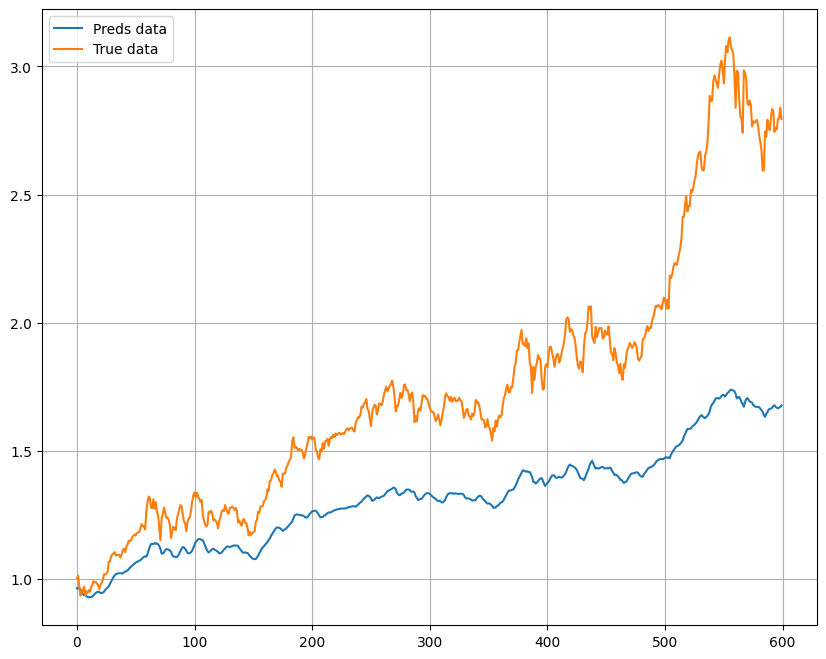

In [95]:
plt.figure(figsize=(10,8))
plt.plot(preds[:600], label = 'Preds data')
plt.plot(trues[:600], label = 'True data')
plt.legend()
plt.grid(True)
plt.show()